# Explore wave spectra

Wave spectral density describes how wave energy is distributed across frequency. Inspect a single spectrum, then follow its evolution through time.

The first code cell records when this notebook was executed against NOAA services.


In [1]:
from datetime import datetime, timezone
print("NOAA execution started (UTC):", datetime.now(timezone.utc).isoformat())

import matplotlib.pyplot as plt
import xndbc

station_id = "41018"
year = 1996

## Select spectral wave density

`mode="swden"` selects spectral density. Its observations have a `frequency` dimension in addition to station and time.

In [2]:
xndbc.list_modes().sel(mode="swden")

<xarray.Dataset> Size: 202B
Dimensions:      ()
Coordinates:
    mode         <U6 24B 'swden'
Data variables:
    description  <U44 176B 'Wave spectral density'
    historical   bool 1B True
    realtime     bool 1B True

## Download and inspect

`SWDEN` carries spectral density; its attributes describe the units. Frequencies are expressed in Hz. Missing frequencies or measurements remain missing. The full observation dataset uses `station_id`, `time`, and `frequency`; timestamps are UTC. Realtime spectral density also includes `SEP_FREQ` when supplied by NOAA. Select a frequency or reduce explicitly before making a simple time series.

In [3]:
data = xndbc.historical(station_id, years=year, mode="swden", progress=False)
spectrum = data.SWDEN.sel(station_id=station_id)
spectrum

<xarray.DataArray 'SWDEN' (time: 1080, frequency: 38)> Size: 328kB
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [0.  , 0.  , 0.  , ..., 0.09, 0.09, 0.1 ],
       [0.  , 0.  , 0.  , ..., 0.12, 0.08, 0.06],
       ...,
       [0.  , 0.  , 0.  , ..., 0.1 , 0.09, 0.08],
       [0.  , 0.  , 0.  , ..., 0.09, 0.07, 0.06],
       [0.  , 0.  , 0.  , ..., 0.1 , 0.08, 0.06]], shape=(1080, 38))
Coordinates:
  * time          (time) datetime64[us] 9kB 1996-01-01 ... 1996-02-14T23:00:00
  * frequency     (frequency) float64 304B 0.03 0.04 0.05 0.06 ... 0.38 0.39 0.4
    station_id    <U5 20B '41018'
    latitude      float64 8B 15.0
    longitude     float64 8B -75.0
    name          <U76 304B ''
    owner         <U3 12B 'N'
    station_type  <U40 160B '3-meter discus buoy'
    notes         <U990 4kB ''
Attributes:
    long_name:  Wave spectral density
    units:      m2 Hz-1

## Plot one observation

Some timestamps have no spectral measurements. Drop those empty rows and select the first remaining observation. The horizontal axis is frequency, not time.

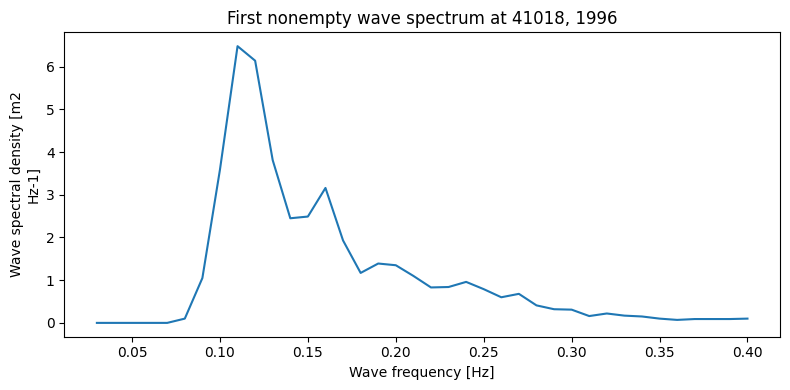

In [4]:
observed = spectrum.dropna("time", how="all")
observed.isel(time=0).plot.line(x="frequency", figsize=(8, 4))
plt.title(f"First nonempty wave spectrum at {station_id}, {year}")
plt.tight_layout()
plt.show()

## Follow the spectrum through time

The color plot retains both time and frequency. It shows the available observations, rather than assuming the archive file covers a full calendar year.

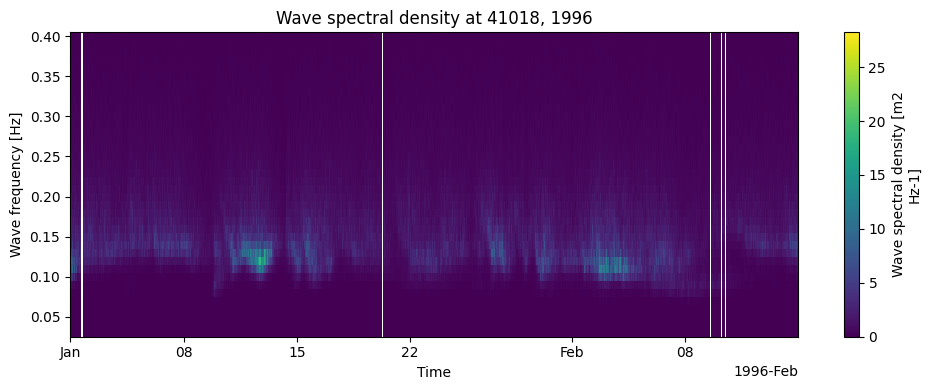

In [5]:
spectrum.plot.pcolormesh(x="time", y="frequency", figsize=(10, 4))
plt.title(f"Wave spectral density at {station_id}, {year}")
plt.tight_layout()
plt.show()

Explore other supported products with `xndbc.list_modes()`. Continue to [Finding Stations](finding_stations.ipynb) or [Current Profiles](current_profiles.ipynb).